In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.exceptions import ConvergenceWarning

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



In [2]:
# =========================
# 0) CONFIG F2 (Week 06)
# =========================

# Prefer repo paths; fall back to the uploaded paths if not found
INPUTS_PATH = "data/F2/initial_inputs.npy"
OUTPUTS_PATH = "data/F2/initial_outputs.npy"

if not os.path.exists(INPUTS_PATH):
    INPUTS_PATH = "/mnt/data/initial_inputs.npy"
if not os.path.exists(OUTPUTS_PATH):
    OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# F2 search space
BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
], dtype=float)

MAXIMIZE = True  # F2: maximize log-likelihood score

# Acquisition (EI)
XI = 0.03  # exploration parameter (keep slightly >0 due to noise)

# Candidate generation
N_CAND_GLOBAL = 60000
N_CAND_LOCAL  = 15000
LOCAL_SIGMA   = 0.05   # tighter local search as optimum stabilises   # slightly tighter local search as data grows

# Diversity constraint (avoid picking almost-duplicate points)
MIN_DIST = 0.02

# Reproducibility
RANDOM_SEED = 42

# Output requirement: ONE row only
BATCH_SIZE = 1

# Plot grids (2D contour)
GRID_N = 120


In [3]:
# =========================
# 1) LOAD DATA
# =========================

X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

X = np.asarray(X, dtype=float)
y = np.asarray(y, dtype=float).ravel()

assert X.ndim == 2 and X.shape[1] == 2, f"Expected X shape (n,2), got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"y must be (n,), got {y.shape} for X {X.shape}"

n = X.shape[0]
best_idx = int(np.argmax(y)) if MAXIMIZE else int(np.argmin(y))
x_best_obs = X[best_idx]
y_best_obs = float(y[best_idx])

print(f"[DATA] n={n}, dims={X.shape[1]}")
print(f"[DATA] y: min={y.min():.6f}, mean={y.mean():.6f}, max={y.max():.6f}, std={y.std(ddof=1):.6f}")
print(f"[DATA] best observed idx={best_idx}, x_best={x_best_obs}, y_best={y_best_obs:.6f}")



[DATA] n=15, dims=2
[DATA] y: min=-0.067298, mean=0.218376, max=0.611205, std=0.251717
[DATA] best observed idx=9, x_best=[0.70263656 0.9265642 ], y_best=0.611205


In [4]:
# =========================
# 2) SURROGATE (GP + RF ensemble + GBM ensemble)
# =========================

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ---- Gaussian Process (primary)
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-2, 5.0), nu=2.5) \
         + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,              # numerical stability (not observation noise)
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED
)
gp.fit(X, y)

# ---- Random Forest ensemble (uncertainty via prediction spread)
rf_seeds = [0, 1, 2, 3, 4]
rf_ens = []
for s in rf_seeds:
    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=1000 + s,
        bootstrap=True,
        min_samples_leaf=2,
        n_jobs=-1
    )
    rf.fit(X, y)
    rf_ens.append(rf)

# ---- GBM ensemble (uncertainty via prediction spread)
gbm_seeds = [0, 1, 2, 3, 4]
gbm_ens = []
for s in gbm_seeds:
    gbm = GradientBoostingRegressor(
        random_state=2000 + s,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9
    )
    gbm.fit(X, y)
    gbm_ens.append(gbm)

print("\n[SURROGATE] GP kernel after fit:\n", gp.kernel_)


def gp_predict_mean_std(model: GaussianProcessRegressor, Xq: np.ndarray):
    mu, std = model.predict(Xq, return_std=True)
    std = np.maximum(std, 1e-12)
    return mu, std


def ensemble_predict_mean_std(models, Xq: np.ndarray):
    preds = np.vstack([m.predict(Xq) for m in models])  # (m, n)
    mu = preds.mean(axis=0)
    std = preds.std(axis=0, ddof=1) if preds.shape[0] > 1 else np.zeros_like(mu)
    std = np.maximum(std, 1e-12)
    return mu, std




[SURROGATE] GP kernel after fit:
 0.927**2 * Matern(length_scale=[0.0649, 5], nu=2.5) + WhiteKernel(noise_level=0.00921)


In [5]:
# =========================
# 3) ACQUISITION (Expected Improvement) + NEXT X
# =========================

rng = np.random.default_rng(RANDOM_SEED)

def sample_uniform(n_samp: int, bounds: np.ndarray) -> np.ndarray:
    lo = bounds[:, 0]
    hi = bounds[:, 1]
    return rng.uniform(lo, hi, size=(n_samp, bounds.shape[0]))

def sample_local_around(x0: np.ndarray, n_samp: int, sigma: float, bounds: np.ndarray) -> np.ndarray:
    Xl = rng.normal(loc=x0, scale=sigma, size=(n_samp, x0.size))
    # clip to bounds
    Xl = np.clip(Xl, bounds[:, 0], bounds[:, 1])
    return Xl

def min_dist_to_existing(Xcand: np.ndarray, Xtrain: np.ndarray) -> np.ndarray:
    # returns min Euclidean distance from each candidate to any existing point
    # (n_cand, n_train, d) -> (n_cand, n_train) -> (n_cand,)
    diffs = Xcand[:, None, :] - Xtrain[None, :, :]
    d2 = np.sum(diffs * diffs, axis=2)
    return np.sqrt(np.min(d2, axis=1))

def expected_improvement(mu: np.ndarray, sigma: np.ndarray, y_best: float, xi: float, maximize: bool = True) -> np.ndarray:
    # EI for maximization: imp = mu - y_best - xi
    # EI for minimization: imp = y_best - mu - xi
    if maximize:
        imp = mu - y_best - xi
    else:
        imp = y_best - mu - xi

    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    # If sigma == 0 => EI should be 0
    ei = np.where(sigma <= 1e-12, 0.0, ei)
    return np.maximum(ei, 0.0)

# Generate candidates
Xcand_global = sample_uniform(N_CAND_GLOBAL, BOUNDS)
Xcand_local  = sample_local_around(x_best_obs, N_CAND_LOCAL, LOCAL_SIGMA, BOUNDS)
Xcand = np.vstack([Xcand_global, Xcand_local])

# Enforce diversity vs existing points
dmin = min_dist_to_existing(Xcand, X)
mask = dmin >= MIN_DIST
Xcand = Xcand[mask]

print(f"\n[ACQ] candidates kept after MIN_DIST filter: {Xcand.shape[0]}")

# Evaluate EI using GP
mu_gp, std_gp = gp_predict_mean_std(gp, Xcand)
ei = expected_improvement(mu_gp, std_gp, y_best_obs, XI, maximize=MAXIMIZE)

best_cand_idx = int(np.argmax(ei))
x_next = Xcand[best_cand_idx].reshape(1, -1)

print(f"[ACQ] best EI={ei[best_cand_idx]:.6e}")
print(f"[ACQ] x_next = {x_next.flatten()}")




[ACQ] candidates kept after MIN_DIST filter: 72858
[ACQ] best EI=3.836450e-03
[ACQ] x_next = [0.68532237 1.        ]


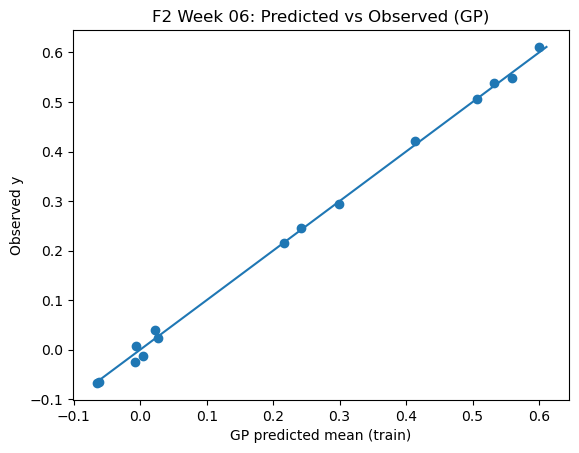

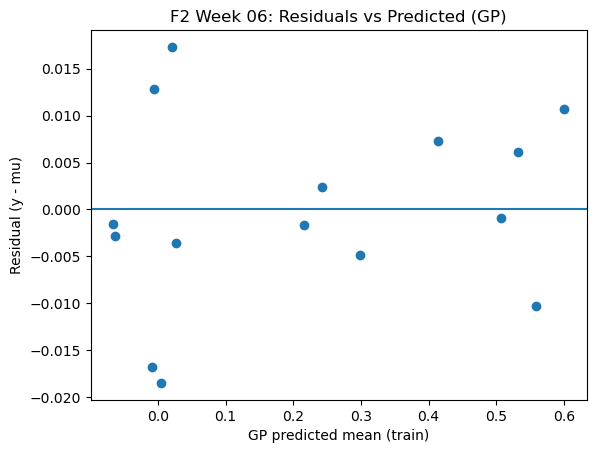

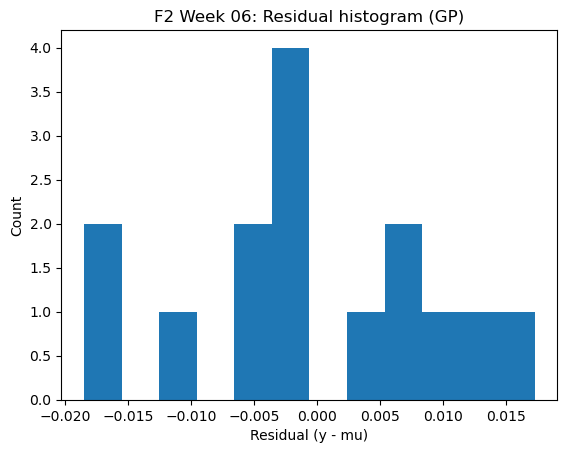

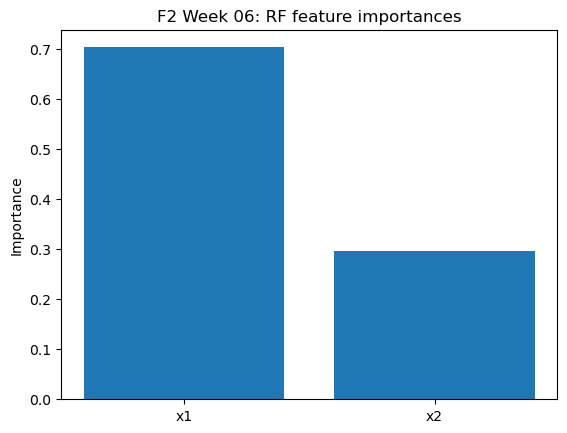

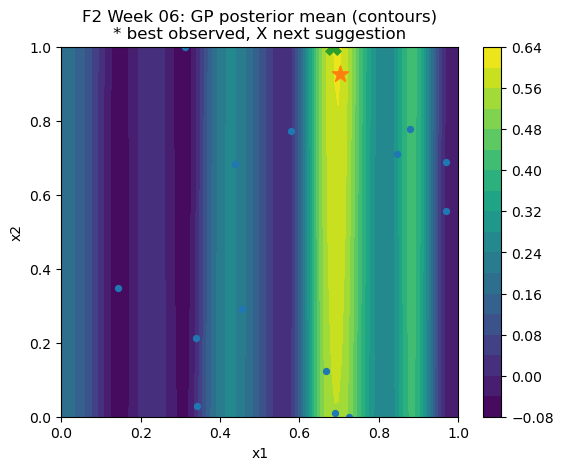

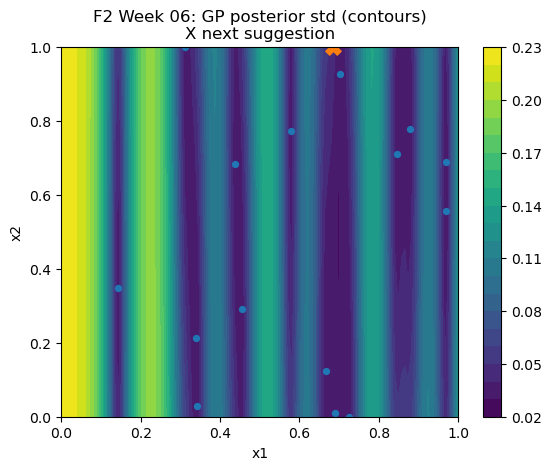


[DIAG] distance(x_next, nearest existing) = 0.0754 (MIN_DIST=0.02)

[DIAG] surrogate predictions at x_next
  GP : mu=0.599724, std=0.043025
  RF : mu=0.428855, std=0.006773
  GBM: mu=0.603233, std=0.004646


In [6]:
# =========================
# 4) DIAGNOSTICS
# =========================

# ---- Predicted vs observed (train)
mu_train, std_train = gp_predict_mean_std(gp, X)
resid = y - mu_train

plt.figure()
plt.scatter(mu_train, y)
mn = min(mu_train.min(), y.min())
mx = max(mu_train.max(), y.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("GP predicted mean (train)")
plt.ylabel("Observed y")
plt.title("F2 Week 06: Predicted vs Observed (GP)")
plt.show()

plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0.0)
plt.xlabel("GP predicted mean (train)")
plt.ylabel("Residual (y - mu)")
plt.title("F2 Week 06: Residuals vs Predicted (GP)")
plt.show()

plt.figure()
plt.hist(resid, bins=12)
plt.xlabel("Residual (y - mu)")
plt.ylabel("Count")
plt.title("F2 Week 06: Residual histogram (GP)")
plt.show()

# ---- Feature importances (RF)
rf0 = rf_ens[0]
importances = rf0.feature_importances_

plt.figure()
plt.bar([0, 1], importances)
plt.xticks([0, 1], ["x1", "x2"])
plt.ylabel("Importance")
plt.title("F2 Week 06: RF feature importances")
plt.show()

# ---- Contours for GP mean + uncertainty (2D)
x1_lin = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], GRID_N)
x2_lin = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], GRID_N)
X1g, X2g = np.meshgrid(x1_lin, x2_lin)
Xgrid = np.column_stack([X1g.ravel(), X2g.ravel()])

mu_g, std_g = gp_predict_mean_std(gp, Xgrid)
MU = mu_g.reshape(GRID_N, GRID_N)
STD = std_g.reshape(GRID_N, GRID_N)

plt.figure()
cs = plt.contourf(X1g, X2g, MU, levels=20)
plt.colorbar(cs)
plt.scatter(X[:, 0], X[:, 1], s=18)
plt.scatter(x_best_obs[0], x_best_obs[1], marker="*", s=150)
plt.scatter(x_next[0, 0], x_next[0, 1], marker="X", s=120)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F2 Week 06: GP posterior mean (contours)\n* best observed, X next suggestion")
plt.show()

plt.figure()
cs = plt.contourf(X1g, X2g, STD, levels=20)
plt.colorbar(cs)
plt.scatter(X[:, 0], X[:, 1], s=18)
plt.scatter(x_next[0, 0], x_next[0, 1], marker="X", s=120)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("F2 Week 06: GP posterior std (contours)\nX next suggestion")
plt.show()

# ---- “Not stuck in one region” quick check: nearest-neighbour distance of x_next
d_next = float(min_dist_to_existing(x_next, X)[0])
print(f"\n[DIAG] distance(x_next, nearest existing) = {d_next:.4f} (MIN_DIST={MIN_DIST})")

# Optional: compare surrogates at x_next
mu_rf, std_rf = ensemble_predict_mean_std(rf_ens, x_next)
mu_gbm, std_gbm = ensemble_predict_mean_std(gbm_ens, x_next)
mu_gp_next, std_gp_next = gp_predict_mean_std(gp, x_next)

print("\n[DIAG] surrogate predictions at x_next")
print(f"  GP : mu={float(mu_gp_next[0]):.6f}, std={float(std_gp_next[0]):.6f}")
print(f"  RF : mu={float(mu_rf[0]):.6f}, std={float(std_rf[0]):.6f}")
print(f"  GBM: mu={float(mu_gbm[0]):.6f}, std={float(std_gbm[0]):.6f}")



In [7]:
# =========================
# 5) OUTPUT (one line for tutor)
# =========================

# Print exactly one line (x1 x2) for submission
x1_out, x2_out = x_next.flatten()
print("\n=== SUBMIT THIS X (one row) ===")
print(f"{x1_out:.8f} {x2_out:.8f}")

# Also save to file for convenience
os.makedirs("outputs", exist_ok=True)
np.save("outputs/F2_week06_x_next.npy", x_next)
with open("outputs/F2_week06_x_next.txt", "w") as f:
    f.write(f"{x1_out:.8f} {x2_out:.8f}\n")

print("\n[OUTPUT] saved to outputs/F2_week06_x_next.npy and outputs/F2_week06_x_next.txt")


=== SUBMIT THIS X (one row) ===
0.68532237 1.00000000

[OUTPUT] saved to outputs/F2_week06_x_next.npy and outputs/F2_week06_x_next.txt
